# Working with Categorical Data in Python
## Course Summary Notebook

---

## Chapter 1: Introduction to Categorical Data in pandas

**What is categorical data?**  
Categorical data has a finite number of groups (categories) that are usually fixed or known (e.g., eye color, marital status). It is *qualitative*, in contrast to *numerical* (quantitative) data like height or weight.

- **Ordinal variables** — categorical with a natural order (e.g., short < medium < long)
- **Nominal variables** — categorical without a natural order (e.g., eye color, breed)

### Exploring categorical columns

In [1]:
import pandas as pd

# Load dataset
adult = pd.read_csv('adult.csv')

# Quick summary of a categorical column
adult['Marital Status'].describe()

count                   32561
unique                      7
top        Married-civ-spouse
freq                    14976
Name: Marital Status, dtype: object

In [3]:
# Frequency counts
adult['Marital Status'].value_counts()

 Married-civ-spouse       14976
 Never-married            10683
 Divorced                  4443
 Separated                 1025
 Widowed                    993
 Married-spouse-absent      418
 Married-AF-spouse           23
Name: Marital Status, dtype: int64

In [4]:
# Proportions
adult['Marital Status'].value_counts(normalize=True)

 Married-civ-spouse       0.459937
 Never-married            0.328092
 Divorced                 0.136452
 Separated                0.031479
 Widowed                  0.030497
 Married-spouse-absent    0.012837
 Married-AF-spouse        0.000706
Name: Marital Status, dtype: float64

### Setting the categorical dtype

In [2]:
# Convert a column to category
adult['Marital Status'] = adult['Marital Status'].astype('category')
adult['Marital Status'].dtype

## adult['Marital Status'].astype('int64')
## adult['Marital Status'].astype('float64')
## adult['Marital Status'].astype('str')
## adult['Marital Status'].astype('bool')

CategoricalDtype(categories=[' Divorced', ' Married-AF-spouse', ' Married-civ-spouse',
                  ' Married-spouse-absent', ' Never-married', ' Separated',
                  ' Widowed'],
                 ordered=False)

In [3]:
# Specify dtype at read time
adult_dtypes = {'Marital Status': 'category'}
adult = pd.read_csv('adult.csv', dtype=adult_dtypes)

In [4]:
# Create a categorical Series manually
my_data = ['A', 'A', 'C', 'B', 'C', 'A']
my_series1 = pd.Series(my_data, dtype='category')
print(my_series1)

# Create an ordered categorical Series
my_series2 = pd.Categorical(my_data, categories=['C', 'B', 'A'], ordered=True)
print(my_series2)

0    A
1    A
2    C
3    B
4    C
5    A
dtype: category
Categories (3, object): ['A', 'B', 'C']
['A', 'A', 'C', 'B', 'C', 'A']
Categories (3, object): ['C' < 'B' < 'A']


### Memory savings

In [6]:
# Compare memory usage: object vs category
print('As object:  ', adult['Marital Status'].astype('object').nbytes)
print('As category:', adult['Marital Status'].astype('category').nbytes)

## the memory usage difference between object and category is significant

As object:   260488
As category: 32617


### Grouping with `.groupby()`

In [5]:
adult['Above/Below 50k'].value_counts()

 <=50K    24720
 >50K      7841
Name: Above/Below 50k, dtype: int64

In [12]:
# Basic groupby
adult.groupby(by=['Above/Below 50k']).mean()

,Age,fnlgwt,Education Num,Capital Gain,Capital Loss,Hours/Week
Above/Below 50k,,,,,,
<=50K,36.783738,190340.86517,9.595065,148.752468,53.142921,38.840210
>50K,44.249841,188005.00000,11.611657,4006.142456,195.001530,45.473026


In [13]:
# Groupby with column selection (preferred for large datasets)
adult.groupby(by=['Above/Below 50k'])[['Age', 'Education Num']].sum()

,Age,Education Num
Above/Below 50k,,
<=50K,909294,237190
>50K,346963,91047


In [14]:
# Groupby multiple columns
adult.groupby(by=['Above/Below 50k', 'Marital Status']).size()

Above/Below 50k  Marital Status        
 <=50K            Divorced                  3980
                  Married-AF-spouse           13
                  Married-civ-spouse        8284
                  Married-spouse-absent      384
                  Never-married            10192
                  Separated                  959
                  Widowed                    908
 >50K             Divorced                   463
                  Married-AF-spouse           10
                  Married-civ-spouse        6692
                  Married-spouse-absent       34
                  Never-married              491
                  Separated                   66
                  Widowed                     85
dtype: int64

---
## Chapter 2: Setting, Updating, and Cleaning Categories

The `.cat` accessor is used to work with categorical Series.

| Method | Effect |
|--------|--------|
| `cat.set_categories()` | Replaces category list; unlisted values → NaN |
| `cat.add_categories()` | Adds categories without changing data |
| `cat.remove_categories()` | Removed values → NaN |
| `cat.rename_categories()` | Renames categories (new names must be unique) |
| `cat.reorder_categories()` | Changes display/sort order |

### Setting and ordering categories

In [7]:
dogs = pd.read_csv('ShelterDogs.csv')

In [8]:
dogs['coat'].value_counts()

short         1972
medium         565
wirehaired     220
long           180
Name: coat, dtype: int64

In [9]:
dogs['coat'] = dogs['coat'].astype('category')

# Set specific categories (others become NaN)
dogs['coat'] = dogs['coat'].cat.set_categories(
    new_categories=['short', 'medium', 'long']
)

# Set with order
dogs['coat'] = dogs['coat'].cat.set_categories(
    new_categories=['short', 'medium', 'long'],
    ordered=True
)
print(dogs['coat'].head(3))

0    short
1    short
2    short
Name: coat, dtype: category
Categories (3, object): ['short' < 'medium' < 'long']


### Adding and removing categories

In [20]:
# Add categories without changing existing data
dogs['likes_people'] = dogs['likes_people'].astype('category')
dogs['likes_people'] = dogs['likes_people'].cat.add_categories(
    new_categories=['did not check', 'could not tell']
)
print(dogs['likes_people'].cat.categories)

Index(['no', 'yes', 'did not check', 'could not tell'], dtype='object')


In [23]:
# Remove a category (matching values become NaN)
dogs['coat'] = dogs['coat'].cat.remove_categories(removals=['wirehaired'])
print(dogs['coat'].cat.categories)

ValueError: removals must all be in old categories: {'wirehaired'}

### Renaming categories

In [25]:
dogs['breed'] = dogs['breed'].astype('category')

In [26]:
# Rename with a dictionary
my_changes = {'Unknown Mix': 'Unknown'}
dogs['breed'] = dogs['breed'].cat.rename_categories(my_changes)

In [28]:
dogs['sex'] = dogs['sex'].astype('category')

In [29]:
# Rename with a function
dogs['sex'] = dogs['sex'].cat.rename_categories(lambda c: c.title())
print(dogs['sex'].cat.categories)

Index(['Female', 'Male'], dtype='object')


### Collapsing categories
> `rename_categories()` cannot map two old names to the same new name. Use `.replace()` instead.

In [30]:
update_colors = {
    'black and brown': 'black',
    'black and tan':   'black',
    'black and white': 'black',
}
dogs['main_color'] = dogs['color'].replace(update_colors)
dogs['main_color'] = dogs['main_color'].astype('category')  # re-cast after replace

### Reordering categories

In [31]:
dogs['coat'] = dogs['coat'].cat.reorder_categories(
    new_categories=['short', 'medium', 'wirehaired', 'long'],
    ordered=True
)
dogs.groupby(by=['coat'])['age'].mean()

ValueError: items in new_categories are not the same as in old categories

### Cleaning dirty categorical data

In [12]:
dogs['get_along_cats'].dtype

dtype('O')

In [33]:
# 1. Remove whitespace
dogs['get_along_cats'] = dogs['get_along_cats'].str.strip()

# 2. Standardize capitalization
dogs['get_along_cats'] = dogs['get_along_cats'].str.title()

# 3. Fix typos
dogs['get_along_cats'] = dogs['get_along_cats'].replace({'Noo': 'No'})

# 4. Re-cast to category
dogs['get_along_cats'] = dogs['get_along_cats'].astype('category')

### Searching and filtering

In [34]:
# Search within a column
dogs['breed'].str.contains('Shepherd', regex=False)

0       False
1       False
2       False
3       False
4       False
        ...  
2932    False
2933    False
2934    False
2935    False
2936     True
Name: breed, Length: 2937, dtype: bool

In [35]:
# Filter rows and access another column
dogs.loc[dogs['get_along_cats'] == 'Yes', 'size'].value_counts(sort=False)

large      37
small      69
medium    169
Name: size, dtype: int64

---
## Chapter 3: Categorical Plots with Seaborn

`sns.catplot()` is the single entry point for all categorical plot types.

| `kind=` | Description |
|---------|-------------|
| `'box'` | Box-and-whisker |
| `'bar'` | Mean + confidence interval as bars |
| `'point'` | Mean + CI as connected points |
| `'count'` | Frequency counts |
| `'strip'` | Jittered scatter |
| `'violin'` | Distribution shape |

### Box plot

In [36]:
reviews = pd.read_csv('lasvegas_tripadvisor.csv')

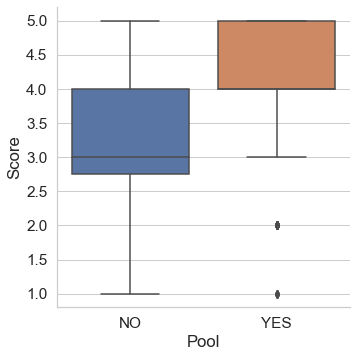

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.4)
sns.set_style('whitegrid')

sns.catplot(x='Pool', y='Score', data=reviews, kind='box')
plt.show()

### Bar plot with `hue`

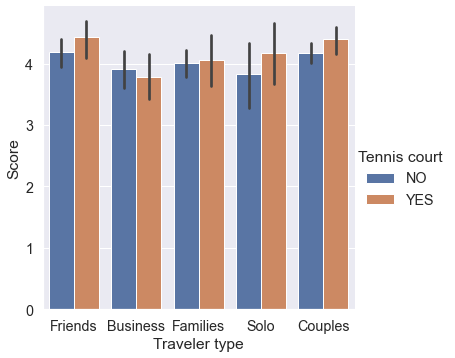

In [38]:
sns.set(font_scale=1.3)
sns.set_style('darkgrid')

sns.catplot(
    x='Traveler type',
    y='Score',
    data=reviews,
    kind='bar',
    hue='Tennis court'  # split by second category
)
plt.show()

### Point plot

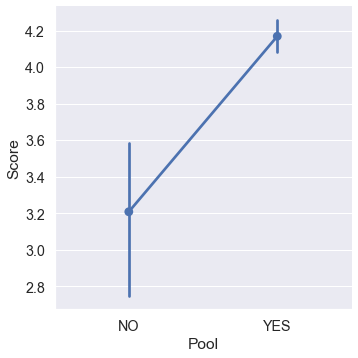

In [39]:
# Basic point plot
sns.catplot(x='Pool', y='Score', data=reviews, kind='point')
plt.show()

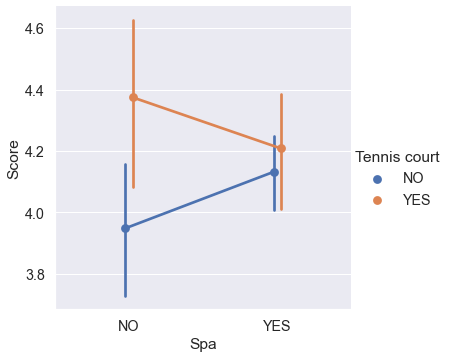

In [40]:
# Point plot with hue and dodge
sns.catplot(
    x='Spa', y='Score', data=reviews,
    kind='point',
    hue='Tennis court',
    dodge=True   # separate the hue groups
)
plt.show()

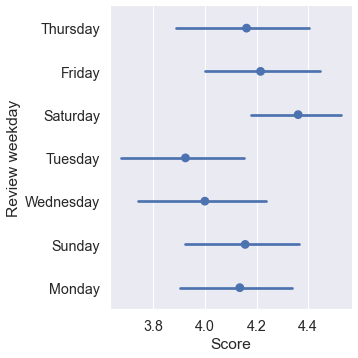

In [41]:
# Remove connecting lines with join=False
sns.catplot(
    x='Score', y='Review weekday',
    data=reviews, kind='point',
    join=False
)
plt.show()

### Count plot

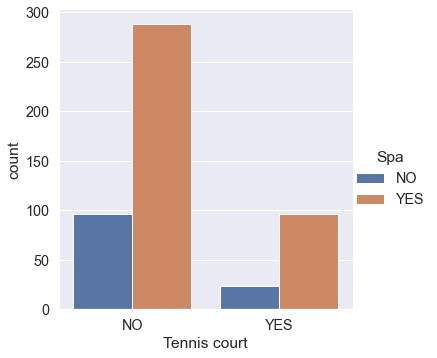

In [42]:
sns.catplot(x='Tennis court', data=reviews, kind='count', hue='Spa')
plt.show()

### Facet grid (small multiples)

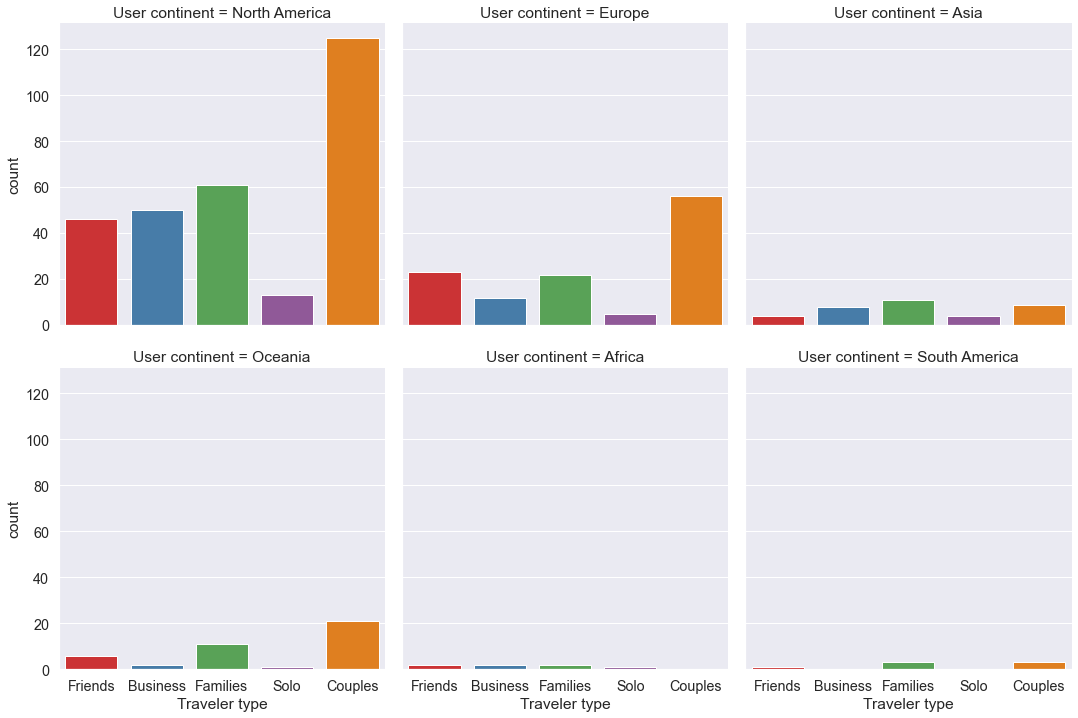

In [43]:
sns.catplot(
    x='Traveler type',
    kind='count',
    col='User continent',
    col_wrap=3,
    palette=sns.color_palette('Set1'),
    data=reviews
)
plt.show()

### Updating plot titles and labels

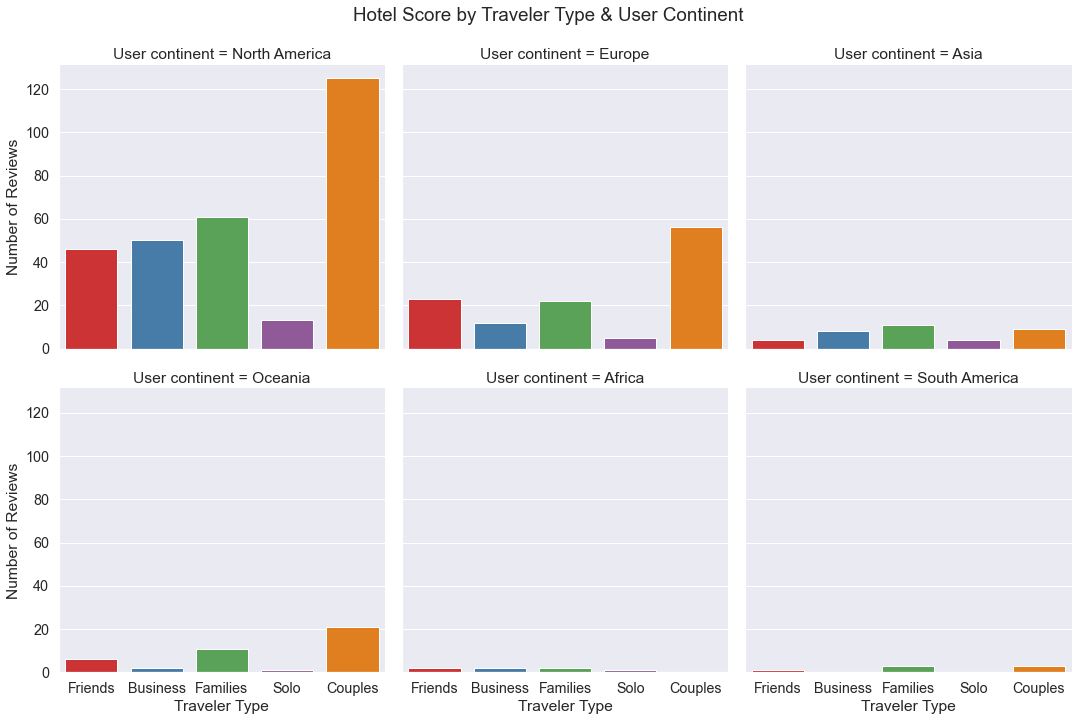

In [44]:
ax = sns.catplot(
    x='Traveler type', col='User continent', col_wrap=3,
    kind='count', palette=sns.color_palette('Set1'), data=reviews
)

ax.fig.suptitle('Hotel Score by Traveler Type & User Continent')
ax.set_axis_labels('Traveler Type', 'Number of Reviews')
plt.subplots_adjust(top=0.9)
plt.show()

---
## Chapter 4: Categorical Pitfalls & Encoding

### Common pitfalls

- `.str` accessor → converts category to **object**; must re-cast afterward
- `.apply()` → always returns **object** dtype
- NumPy aggregations (`.sum()`, `.mean()`) raise `TypeError` on categoricals — cast to numeric first
- `set_categories()`, `add_categories()`, `remove_categories()` handle missing values differently

### Pitfall: `.str` resets dtype

In [14]:
used_cars = pd.read_csv('lasvegas_tripadvisor.csv')

In [15]:
used_cars.dtypes

User country         object
Nr. reviews           int64
Nr. hotel reviews     int64
Helpful votes         int64
Score                 int64
Period of stay       object
Traveler type        object
Pool                 object
Gym                  object
Tennis court         object
Spa                  object
Casino               object
Free internet        object
Hotel name           object
Hotel stars           int64
Nr. rooms             int64
User continent       object
Member years          int64
Review month         object
Review weekday       object
dtype: object

In [ ]:
used_cars['color'] = used_cars['color'].astype('category')
used_cars['color'] = used_cars['color'].str.upper()   # dtype is now object!
print(used_cars['color'].dtype)  # object

# Fix: re-cast
used_cars['color'] = used_cars['color'].astype('category')
print(used_cars['color'].dtype)  # category

### Pitfall: NumPy operations on categoricals

In [ ]:
# This raises TypeError:
# used_cars['number_of_photos'].astype('category').sum()

# Fix: cast to int first
used_cars['number_of_photos'].astype(int).sum()

### When categorical saves memory (and when it doesn't)

In [ ]:
# High savings: few unique values relative to row count
print('manufacturer_name as object:  ', used_cars['manufacturer_name'].nbytes)
print('manufacturer_name as category:', used_cars['manufacturer_name'].astype('category').nbytes)

# Low savings: many unique values
print('odometer_value as float:   ', used_cars['odometer_value'].nbytes)
print('odometer_value as category:', used_cars['odometer_value'].astype('category').nbytes)

### Label encoding

Assigns each category an integer code from `0` to `n-1`. Missing values get `-1`.  
**Drawback:** implies a false ordinal relationship — not ideal for ML.

In [13]:
used_cars['manufacturer_name'] = used_cars['manufacturer_name'].astype('category')
used_cars['manufacturer_code'] = used_cars['manufacturer_name'].cat.codes
print(used_cars[['manufacturer_name', 'manufacturer_code']].head())

NameError: name 'used_cars' is not defined

In [ ]:
# Build a code book to decode labels back
name_map = dict(zip(used_cars['manufacturer_name'].cat.codes,
                    used_cars['manufacturer_name']))
print(name_map)

# Revert codes to original labels
used_cars['manufacturer_code'].map(name_map)

### Boolean encoding

In [ ]:
import numpy as np

# Create a binary 0/1 flag
used_cars['van_code'] = np.where(
    used_cars['body_type'].str.contains('van', regex=False), 1, 0
)
print(used_cars['van_code'].value_counts())

### One-hot encoding

Creates a binary column per category. Best approach for ML — avoids implying ordinal relationships.

In [ ]:
# One-hot encode a single column
used_cars_onehot = pd.get_dummies(used_cars[['odometer_value', 'color']])
print(used_cars_onehot.head())
print(used_cars_onehot.shape)

In [ ]:
# Encode with custom prefix on a full DataFrame
used_cars_onehot = pd.get_dummies(used_cars, columns=['color'], prefix='color')
print(used_cars_onehot.shape)

# Note: NaN values do NOT get their own column
# Note: encoding all columns can explode feature count
# used_cars_onehot = pd.get_dummies(used_cars)  # (38531, 1240)

---
*End of Summary Notebook — Working with Categorical Data in Python*